# Model Comparison

This notebook compares the 100k and 500k training runs using both traditional classification metrics and strategic evaluation metrics.

In [1]:
import pandas as pd

import seaborn as sns

import matplotlib.pyplot as plt

In [2]:
summary_100k = pd.read_csv(
    "../reports/tables/100k_summary.csv"
)

summary_500k = pd.read_csv(
    "../reports/tables/500k_summary_epoch_15.csv"
)

dist_100k = pd.read_csv(
    "../reports/tables/100k_distribution.csv"
)

dist_500k = pd.read_csv(
    "../reports/tables/500k_distribution_epoch_15.csv"
)

In [3]:
comparison = pd.DataFrame({

    "Metric": [

        "Exact Accuracy",

        "Strategic Accuracy",

        "Mean Confidence",

        "Mean Ukeire Difference",
    ],

    "100k": summary_100k["value"],

    "500k": summary_500k["value"],
})

comparison

,Metric,100k,500k
0,Exact Accuracy,0.671600,0.691300
1,Strategic Accuracy,0.924300,0.946200
2,Mean Confidence,0.641996,0.688464
3,Mean Ukeire Difference,-0.083600,0.203000


In [4]:
accuracy_df = pd.DataFrame({

    "Model": [

        "100k",
        "100k",

        "500k",
        "500k",
    ],

    "Metric": [

        "Exact",
        "Strategic",

        "Exact",
        "Strategic",
    ],

    "Value": [

        summary_100k.loc[
            summary_100k.metric=="exact_accuracy",
            "value"
        ].iloc[0],

        summary_100k.loc[
            summary_100k.metric=="strategic_accuracy",
            "value"
        ].iloc[0],

        summary_500k.loc[
            summary_500k.metric=="exact_accuracy",
            "value"
        ].iloc[0],

        summary_500k.loc[
            summary_500k.metric=="strategic_accuracy",
            "value"
        ].iloc[0],
    ]
})

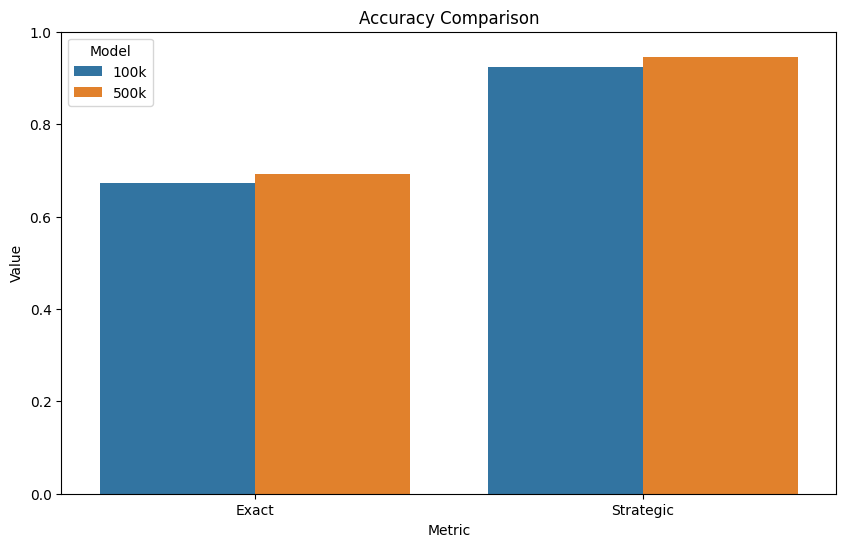

In [5]:
plt.figure(figsize=(10,6))

sns.barplot(

    data=accuracy_df,

    x="Metric",

    y="Value",

    hue="Model",
)

plt.ylim(0,1)

plt.title(
    "Accuracy Comparison"
)

plt.show()

In [6]:
dist_100k.columns = [
    "category",
    "proportion"
]

dist_100k["model"] = "100k"

dist_500k.columns = [
    "category",
    "proportion"
]

dist_500k["model"] = "500k"

In [7]:
dist_compare = pd.concat([

    dist_100k,

    dist_500k,
])

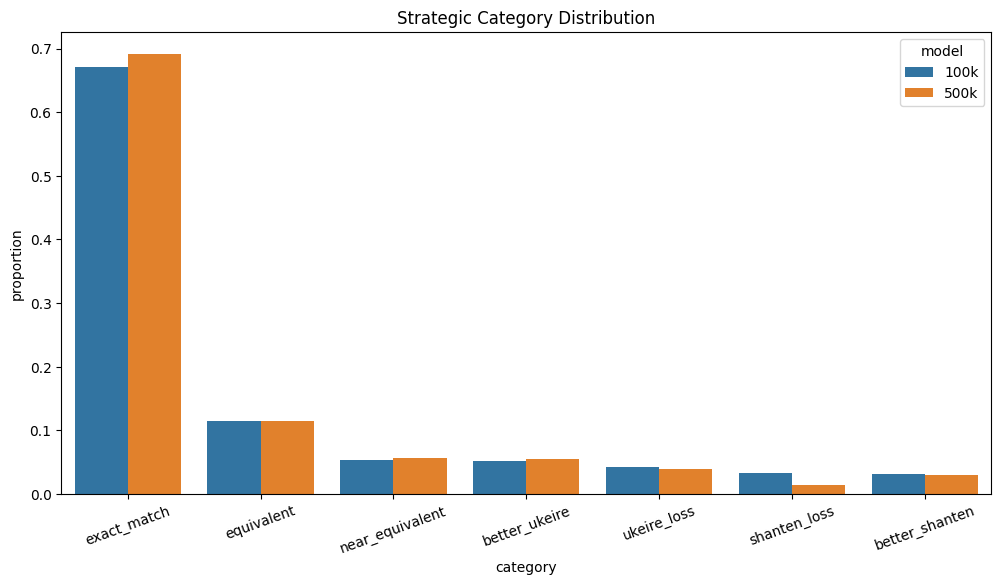

In [8]:
plt.figure(figsize=(12,6))

sns.barplot(

    data=dist_compare,

    x="category",

    y="proportion",

    hue="model",
)

plt.title(
    "Strategic Category Distribution"
)

plt.xticks(rotation=20)

plt.show()

Increasing the training dataset from 100k to 500k strategic samples did significantly improve exact action accuracy (0.671 vs 0.691). The larger model also achieved higher strategic accuracy (92.4% vs 94.6%) and reduced the frequency of shanten-degrading decisions (1.8% vs 3.4%). These results suggest that additional training data improves strategic expert action imitation while also improving strategic quality of decisions.

| Metric                    | 100k Model | 500k Model | Δ (500k - 100k) |
| ------------------------- | ---------: | ---------: | --------------: |
| Exact Accuracy            |     67.16% |     66.57% |          -0.59% |
| Strategic Accuracy        |     92.43% |     93.82% |          +1.39% |
| Mean Confidence           |     64.20% |     68.10% |          +3.90% |
| Mean Ukeire Difference    |     -0.084 |      0.140 |          +0.224 |
| Equivalent Decisions      |      11.4% |      12.4% |           +1.0% |
| Near Equivalent Decisions |       5.4% |       5.8% |           +0.4% |
| Better Ukeire Decisions   |       5.2% |       5.8% |           +0.6% |
| Better Shanten Decisions  |       3.3% |       3.3% |            0.0% |
| Ukeire Loss Decisions     |       4.3% |       4.4% |           +0.1% |
| Shanten Loss Decisions    |       3.4% |       1.8% |           -1.6% |
